In [13]:
# 성인 남녀 얼굴 이미지 분류 - 이진 분류
# data → colab web에서 할 경우 구글 드라이브, 로컬에서 할 경우 로컬 디렉토리에서 불러오기
# 파일명에 label로 사용할 힌트가 있음

import os, cv2, numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

# !cp -r "/content/drive/MyDrive/person_img" "/content/"


print(os.listdir('/content/drive/MyDrive')[:20])

# 데이터 불러오기
image_dir = '/content/drive/MyDrive/person_img' # 구글 드라이브할때, 마운트한 이후 사용
# image_dir = '/content/person_img'
x, y = [], []

# 레이블 구하기
# gender = int(파일명.split('_')[1])   # 파일명에서 성별 정보 추출 0:male, 1:female

for file in os.listdir(image_dir):
    try:
        gender = int(file.split('_')[1])
        img_path = os.path.join(image_dir, file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (64, 64)) # 이미지 크기 조정
        x.append(img)
        y.append(gender)
    except:
        continue

print(x[:3])
print(y[:3])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Colab Notebooks', 'person_img']
[array([[[ 64,  64,  64],
        [ 62,  62,  62],
        [ 61,  61,  61],
        ...,
        [ 61,  61,  61],
        [ 62,  62,  62],
        [ 62,  62,  62]],

       [[ 64,  64,  64],
        [ 62,  62,  62],
        [ 61,  61,  61],
        ...,
        [ 59,  59,  59],
        [ 60,  60,  60],
        [ 60,  60,  60]],

       [[ 63,  63,  63],
        [ 61,  61,  61],
        [ 61,  61,  61],
        ...,
        [ 59,  59,  59],
        [ 59,  59,  59],
        [ 59,  59,  59]],

       ...,

       [[254, 249, 247],
        [241, 236, 235],
        [244, 239, 238],
        ...,
        [188, 116,  32],
        [198, 125,  43],
        [182, 111,  31]],

       [[242, 235, 231],
        [217, 210, 206],
        [208, 202, 198],
        ...,
        [182, 115,  39],
        [186, 119,  44],
        [182, 112,  39]],

Text(0.5, 1.0, 'label : 0 (male)')

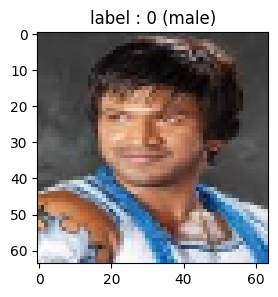

In [4]:
# 첫번째 이미지 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
img_rgb = cv2.cvtColor(x[0], cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title(f'label : {y[0]} ({'male' if y[0] == 0 else 'female'})')

In [5]:
# 정규화
x = np.array(x) / 255.0
y = np.array(y)



# train, test 분할
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)

(102, 64, 64, 3) (26, 64, 64, 3)


In [6]:
# 모델 생성
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(64,64,3)),
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')   # 이진 분류이므로 출력 뉴런 1개, 활성화 함수 sigmoid
])

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # 이진 분류이므로 binary_crossentropy
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=2
)

!nvidia-smi

loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}')

Epoch 1/30
3/3 - 7s - 2s/step - accuracy: 0.6049 - loss: 0.6699 - val_accuracy: 0.3333 - val_loss: 0.7032
Epoch 2/30
3/3 - 0s - 32ms/step - accuracy: 0.6420 - loss: 0.6277 - val_accuracy: 0.8095 - val_loss: 0.5265
Epoch 3/30
3/3 - 0s - 30ms/step - accuracy: 0.6790 - loss: 0.5436 - val_accuracy: 0.5238 - val_loss: 0.7054
Epoch 4/30
3/3 - 0s - 31ms/step - accuracy: 0.7901 - loss: 0.5259 - val_accuracy: 0.8095 - val_loss: 0.5899
Epoch 5/30
3/3 - 0s - 31ms/step - accuracy: 0.8519 - loss: 0.4435 - val_accuracy: 0.7143 - val_loss: 0.6702
Epoch 6/30
3/3 - 0s - 31ms/step - accuracy: 0.8395 - loss: 0.3830 - val_accuracy: 0.9048 - val_loss: 0.6091
Epoch 7/30
3/3 - 0s - 32ms/step - accuracy: 0.8889 - loss: 0.3228 - val_accuracy: 0.5238 - val_loss: 0.8062
Epoch 8/30
3/3 - 0s - 32ms/step - accuracy: 0.9012 - loss: 0.3180 - val_accuracy: 0.9048 - val_loss: 0.6331
Epoch 9/30
3/3 - 0s - 30ms/step - accuracy: 0.8889 - loss: 0.2554 - val_accuracy: 0.5238 - val_loss: 0.8241
Epoch 10/30
3/3 - 0s - 33ms/st

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
예측값 :  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
실제값 :  [1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0]


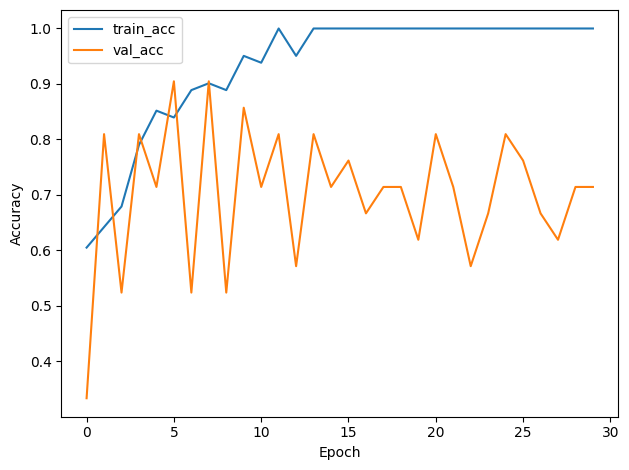

In [9]:
# 예측
pred = model.predict(x_test)
print('예측값 : ', (pred >= 5).astype(int).reshape(-1))
print('실제값 : ', y_test)


# acc 시각화
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label= 'train_acc')
plt.plot(history.history['val_accuracy'], label= 'val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
예측값 :  [1 0 0 1 0]
실제값 :  [1 0 0 0 0]


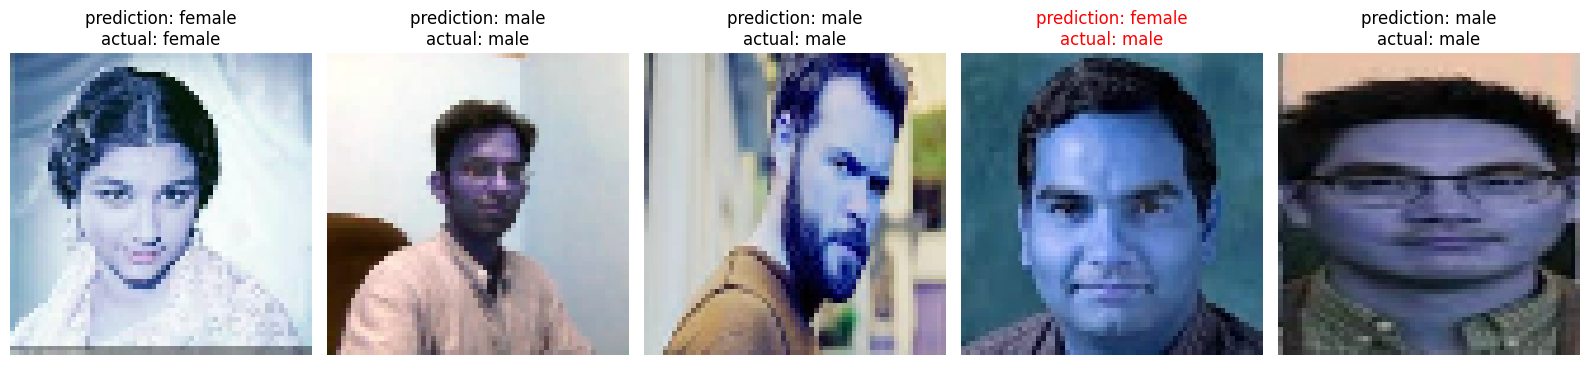

In [ ]:
# 5개의 이미지로 분류 예측 시각화
pred = model.predict(x_test[:5])
pred_classes = (pred > 0.5).astype(int).reshape(-1)
true_classes = y_test[:5]
print('예측값 : ', pred_classes)
print('실제값 : ', true_classes)

plt.figure(figsize=(16, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i])

    is_correct = pred_classes[i] == true_classes[i]
    label = 'female' if true_classes[i] == 1 else 'male'
    prediction = 'female' if pred_classes[i] == 1 else 'male'

    title_color = 'black' if is_correct else 'red'
    plt.title(f'prediction: {prediction}\nactual: {label}', color=title_color)
    plt.axis('off')
plt.tight_layout()
plt.show()

# 현재 모델은 학습 데이터 부족으로 좋은 결과를 기대하기 어렵다
